In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [3]:
datagen=ImageDataGenerator(rescale=1./255, validation_split=0.2, zoom_range=0.2,
                           rotation_range=20, horizontal_flip=True)

In [4]:
train_data=datagen.flow_from_directory("D:\\D\\work\\notes\\DL\\dataset\\flowers",target_size=(150,150),
                                    batch_size=32, class_mode="categorical", subset="training")

Found 3495 images belonging to 2 classes.


In [5]:
val_data=datagen.flow_from_directory("D:\\D\\work\\notes\\DL\\dataset\\flowers",target_size=(150,150),
                                    batch_size=32, class_mode="categorical", subset="validation")

Found 873 images belonging to 2 classes.


In [6]:
model=models.Sequential([
    
    layers.Conv2D(32,(3,3), activation="relu", input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(128,(3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(train_data.num_classes, activation="softmax")
])

c:\Users\Ali Mehdi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [13]:
model.fit(train_data, epochs=5, validation_data=val_data, verbose=1)

Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.7187 - loss: 0.6029 - val_accuracy: 0.7194 - val_loss: 0.6024
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.7187 - loss: 0.6017 - val_accuracy: 0.7194 - val_loss: 0.6020
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.7187 - loss: 0.6023 - val_accuracy: 0.7194 - val_loss: 0.5978
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.7187 - loss: 0.5984 - val_accuracy: 0.7194 - val_loss: 0.6186
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.7185 - loss: 0.5969 - val_accuracy: 0.7194 - val_loss: 0.5966


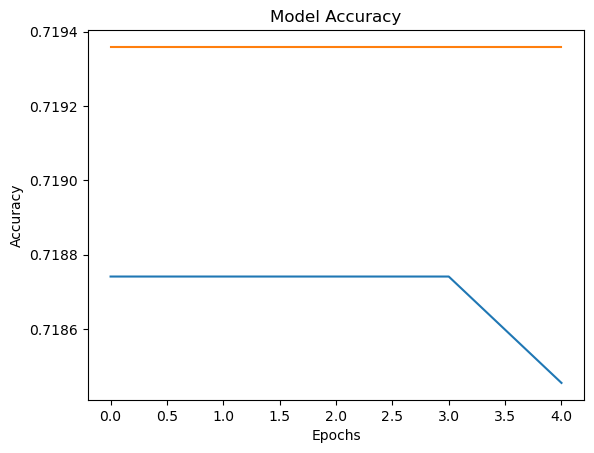

In [14]:
plt.plot(model.history.history["accuracy"], label="train_accuracy")
plt.plot(model.history.history["val_accuracy"], label="val_accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")  
plt.show()

In [23]:
import os
import random
import numpy as np
from tensorflow.keras.preprocessing import image

# 📂 base test folder (5 class folders inside)
base_folder = r"D:\D\work\notes\DL\dataset\flowers\test"

# 🏷️ class folders list
class_folders = os.listdir(base_folder)

# 🎲 random class pick
true_class = random.choice(class_folders)
class_path = os.path.join(base_folder, true_class)

# 🖼️ images list (ONLY files, not folders)
images = os.listdir(class_path)


# 🎲 random image pick
img_name = random.choice(images)
img_path = os.path.join(class_path, img_name)

print("True Class Folder:", true_class)
print("Image Path:", img_path)

# 📷 load image
img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 🔮 prediction
prediction = model.predict(img_array)

class_index = np.argmax(prediction)
confidence = np.max(prediction) * 100

# 🏷️ class names from training
class_labels = list(train_data.class_indices.keys())

print("Predicted Class:", class_labels[class_index])
print("Confidence:", confidence, "%")

True Class Folder: daisy
Image Path: D:\D\work\notes\DL\dataset\flowers\test\daisy\6046940312_8faf552f3e_n.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
Predicted Class: train
Confidence: 76.08794 %


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(train_data.num_classes, activation='softmax')(x)

model_mobilenet = models.Model(inputs=base_model.input, outputs=output)

model_mobilenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_mobilenet = model_mobilenet.fit(train_data, validation_data=val_data, epochs=10)

C:\Users\Ali Mehdi\AppData\Local\Temp\ipykernel_6328\1218139816.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.6813 - loss: 0.7086 - val_accuracy: 0.7159 - val_loss: 0.6069
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.7165 - loss: 0.5948 - val_accuracy: 0.7194 - val_loss: 0.5908
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.7179 - loss: 0.5893 - val_accuracy: 0.7194 - val_loss: 0.5881
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.7187 - loss: 0.5872 - val_accuracy: 0.7194 - val_loss: 0.5837
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 101s 915ms/step - accuracy: 0.7193 - loss: 0.5823 - val_accuracy: 0.7194 - val_loss: 0.6004
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.7239 - loss: 0.5754 - val_accuracy: 0.7194 - val_loss: 0.5902
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 104s 950ms/step - accuracy: 0.7219 - loss: 0.5736 - val_accuracy: 0.7194 - val_loss: 0.5914
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 10